Starting Hyperband...
Best config: {'lr': 0.0032350894049596327, 'wd': 1.689020871383844e-05, 'dropout': 0.5, 'f1': 16, 'f2': 48, 'f3': 64}


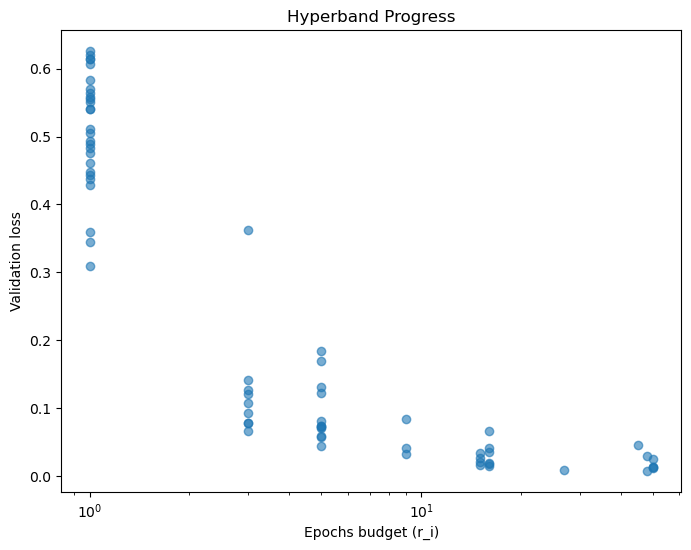

Training best model on train+val for 50 epochs...

=== Held-out Test Split ===
              precision    recall  f1-score   support

     clase_0       1.00      1.00      1.00        64
     clase_1       1.00      1.00      1.00        61

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125

Confusion Matrix:
 [[64  0]
 [ 0 61]]

Loaded 450 unseen images.

=== Unseen Supervised Test ===
              precision    recall  f1-score   support

     clase_0       0.16      0.03      0.05       384
     clase_1       0.00      0.02      0.00        66

    accuracy                           0.03       450
   macro avg       0.08      0.02      0.03       450
weighted avg       0.13      0.03      0.05       450

Confusion Matrix:
 [[ 12 372]
 [ 65   1]]
F1: 0.0046, MCC: -0.8958


In [28]:
#!/usr/bin/env python3
# classic_hyperband_with_progress_fixed.py

import os, random, math
import numpy as np
import pandas as pd
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, f1_score, matthews_corrcoef

# ─── Dataset ────────────────────────────────────────────────────────────────

class GaitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples, self.transform = [], transform
        for lbl, cls in enumerate(["clase_0","clase_1"]):
            folder = os.path.join(root_dir, cls)
            for fn in sorted(os.listdir(folder)):
                if fn.lower().endswith(('.png','.jpg','.jpeg')):
                    self.samples.append((os.path.join(folder,fn), lbl))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, lbl = self.samples[idx]
        img = Image.open(path).convert("L")
        if self.transform: img = self.transform(img)
        return img, torch.tensor(lbl, dtype=torch.long)

# ─── Model Factory ──────────────────────────────────────────────────────────

class ClassicCNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        f1,f2,f3 = cfg['f1'], cfg['f2'], cfg['f3']
        do       = cfg['dropout']
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  f1,3,padding=1), nn.BatchNorm2d(f1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(f1, f2,3,padding=1), nn.BatchNorm2d(f2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(f2, f3,3,padding=1), nn.BatchNorm2d(f3), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(f3*5*3,128), nn.ReLU(), nn.Dropout(do),
            nn.Linear(128,1)
        )
    def forward(self,x):
        return self.classifier(self.encoder(x)).squeeze(1)

# ─── Focal Loss ──────────────────────────────────────────────────────────────

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, labels):
        labelsf = labels.float()
        ce = F.binary_cross_entropy_with_logits(logits, labelsf, reduction="none")
        p  = torch.sigmoid(logits)
        pt = torch.where(labelsf==1, p, 1-p)
        return (self.alpha * (1-pt)**self.gamma * ce).mean()

# ─── Hyperband Utilities ─────────────────────────────────────────────────────

def random_log_uniform(low, high):
    return 10**random.uniform(math.log10(low), math.log10(high))

def random_config():
    return {
        'lr': random_log_uniform(1e-4,1e-2),
        'wd': random_log_uniform(1e-5,1e-3),
        'dropout': random.choice([0.3,0.5,0.7]),
        'f1': random.choice([16,32]),
        'f2': random.choice([32,48]),
        'f3': random.choice([48,64])
    }

def train_epochs(cfg, train_loader, val_loader, epochs, device):
    model = ClassicCNN(cfg).to(device)
    opt   = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    loss_fn = FocalLoss()
    for _ in range(epochs):
        model.train()
        for imgs,lbls in train_loader:
            imgs,lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            loss = loss_fn(model(imgs), lbls)
            loss.backward(); opt.step()
    model.eval()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for imgs,lbls in val_loader:
            imgs,lbls = imgs.to(device), lbls.to(device)
            logits = model(imgs)
            total_loss += F.binary_cross_entropy_with_logits(logits, lbls.float(), reduction='sum').item()
            n += imgs.size(0)
    return total_loss/n, model

def hyperband(train_loader, val_loader, max_epochs=50, eta=3, device='cpu'):
    s_max = int(math.log(max_epochs,eta))
    B = (s_max+1)*max_epochs
    best_cfg, best_score = None, float('inf')
    progress = []  # list of (budget, val_loss)
    for s in reversed(range(s_max+1)):
        n = int(math.ceil(B/max_epochs/(s+1)*(eta**s)))
        r = int(max_epochs*(eta**(-s)))
        configs = [random_config() for _ in range(n)]
        for i in range(s+1):
            n_i = n//(eta**i)
            r_i = r*(eta**i)
            results = []
            for cfg in configs:
                loss,_ = train_epochs(cfg, train_loader, val_loader, r_i, device)
                results.append((cfg, loss))
                progress.append((r_i, loss))
            results.sort(key=lambda x: x[1])
            configs = [cfg for cfg,_ in results[:max(1,n_i//eta)]]
        top_cfg, top_score = results[0]
        if top_score < best_score:
            best_score, best_cfg = top_score, top_cfg
    return best_cfg, progress

# ─── Main Pipeline ──────────────────────────────────────────────────────────

if __name__=="__main__":
    random.seed(42); np.random.seed(42); torch.manual_seed(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_tf = transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])
    eval_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])

    # split indices
    full_train = GaitDataset("processed_images", transform=train_tf)
    full_eval  = GaitDataset("processed_images", transform=eval_tf)
    N = len(full_train)
    idx = list(range(N))
    random.shuffle(idx)
    n_tr = int(0.8*N); n_va = int(0.1*N)
    tr_idx = idx[:n_tr]
    va_idx = idx[n_tr:n_tr+n_va]
    te_idx = idx[n_tr+n_va:]
    tr_ds = Subset(full_train, tr_idx)
    va_ds = Subset(full_eval, va_idx)
    te_ds = Subset(full_eval, te_idx)

    tr_ld = DataLoader(tr_ds, batch_size=32, shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=32, shuffle=False)
    te_ld = DataLoader(te_ds, batch_size=32, shuffle=False)

    print("Starting Hyperband...")
    best_cfg, progress = hyperband(tr_ld, va_ld, max_epochs=50, eta=3, device=device)
    print("Best config:", best_cfg)

    # plot progress
    budgets, losses = zip(*progress)
    plt.figure(figsize=(8,6))
    plt.scatter(budgets, losses, alpha=0.6)
    plt.xscale('log')
    plt.xlabel('Epochs budget (r_i)')
    plt.ylabel('Validation loss')
    plt.title('Hyperband Progress')
    plt.show()

    # final training on train+val
    full_trainval = Subset(full_train, tr_idx+va_idx)
    full_ld = DataLoader(full_trainval, batch_size=32, shuffle=True)
    print("Training best model on train+val for 50 epochs...")
    _, best_model = train_epochs(best_cfg, full_ld, va_ld, 50, device)

    # evaluate held-out test
    print("\n=== Held-out Test Split ===")
    best_model.to(device).eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs,lbls in te_ld:
            imgs = imgs.to(device)
            preds = (torch.sigmoid(best_model(imgs))>=0.5).long().cpu()
            all_p.extend(preds.tolist())
            all_t.extend(lbls.tolist())
    print(classification_report(all_t, all_p, target_names=['clase_0','clase_1']))
    print("Confusion Matrix:\n", confusion_matrix(all_t, all_p))

    # preprocess unseen supervised test
    os.makedirs("processed_test_images", exist_ok=True)
    for cls in ["clase_0","clase_1"]:
        os.makedirs(os.path.join("processed_test_images",cls), exist_ok=True)
    for f in os.listdir("test_supervised"):
        if f.endswith(".xlsx"):
            lbl = "clase_0" if "clase_0" in f else "clase_1"
            arr = pd.read_excel(os.path.join("test_supervised",f)).iloc[:,2:].to_numpy(float)
            mn, mx = arr.min(0), arr.max(0)
            imgarr = ((arr-mn)/(mx-mn)*255).astype(np.uint8)
            for i in range(imgarr.shape[0]//40):
                seg = imgarr[i*40:(i+1)*40,:]
                cv2.imwrite(os.path.join("processed_test_images",lbl,f"{f[:-5]}_{i}.png"), seg)

    unseen_ds = GaitDataset("processed_test_images", transform=eval_tf)
    unseen_ld = DataLoader(unseen_ds, batch_size=32, shuffle=False)
    print(f"\nLoaded {len(unseen_ds)} unseen images.")

    print("\n=== Unseen Supervised Test ===")
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs,lbls in unseen_ld:
            imgs = imgs.to(device)
            preds = (torch.sigmoid(best_model(imgs))>=0.5).long().cpu()
            all_p.extend(preds.tolist())
            all_t.extend(lbls.tolist())
    print(classification_report(all_t, all_p, target_names=['clase_0','clase_1']))
    print("Confusion Matrix:\n", confusion_matrix(all_t, all_p))
    print(f"F1: {f1_score(all_t,all_p):.4f}, MCC: {matthews_corrcoef(all_t,all_p):.4f}")


Overview of this pipeline:

1. Source split: 80 % training, 10 % validation, 10 % held-out test on your processed_images.

2. Unseen split: 20 % of your labelled unseen data for hyperband validation, 80 % for final unseen test.

3. Random configurations include CNN architecture (f1,f2,f3), dropout, lr, wd, domain‐loss weight, and rotation augmentation.

4. Training & scoring (train_and_score) runs a DANN loop for a budget of r_i epochs, then computes F1 on the unseen‐val split.

5. Hyperband uses unseen‐val F1 to prune and pick the best config, logging (r_i, F1) for every trial.

6. A scatter plot shows how F1 evolves with the epoch budget across brackets.

7. The final DANN model is trained on combined source‐train+source‐val plus unseen‐val for 50 epochs and evaluated on both held‐out source and held‐out unseen test splits, reporting full classification reports and confusion matrices.

8. Threshold tuning on the unseen‐test split: picks the cutoff giving ≥60% precision with maximal recall (or falls back to max recall).

9. Final evaluation prints the classification report, confusion matrix, F1 and MCC at that tuned threshold.

Model Parameters: 22,758
Approx. FLOPs per forward pass: 23,242
Epoch 001 | train_loss=2.198, train_acc=0.469 | val_loss=2.134, val_acc=0.503, val_f1=0.668, thr=0.48 | epoch_time=0.02s, batch_time=0.002s, grad_norm=2.54, peak_mem=0.0MB
Epoch 002 | train_loss=2.165, train_acc=0.486 | val_loss=1.878, val_acc=0.497, val_f1=0.634, thr=0.51 | epoch_time=0.02s, batch_time=0.001s, grad_norm=3.92, peak_mem=0.0MB
Epoch 003 | train_loss=2.114, train_acc=0.525 | val_loss=1.947, val_acc=0.475, val_f1=0.636, thr=0.51 | epoch_time=0.02s, batch_time=0.001s, grad_norm=2.57, peak_mem=0.0MB
Epoch 004 | train_loss=2.025, train_acc=0.486 | val_loss=1.904, val_acc=0.553, val_f1=0.649, thr=0.55 | epoch_time=0.02s, batch_time=0.001s, grad_norm=2.52, peak_mem=0.0MB
Epoch 005 | train_loss=2.014, train_acc=0.508 | val_loss=1.902, val_acc=0.544, val_f1=0.688, thr=0.55 | epoch_time=0.01s, batch_time=0.001s, grad_norm=1.71, peak_mem=0.0MB
Epoch 006 | train_loss=1.918, train_acc=0.464 | val_loss=1.835, val_acc=0.54

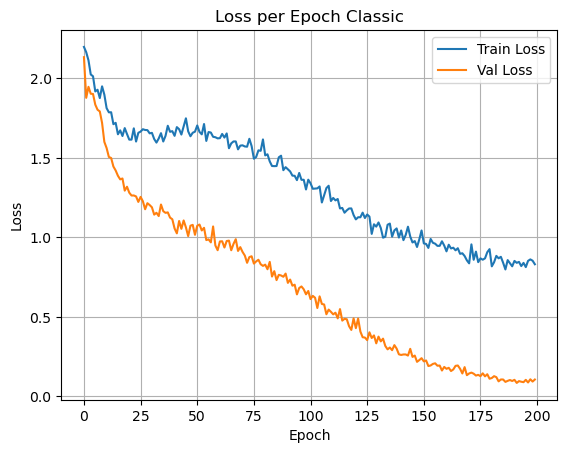

<Figure size 640x480 with 0 Axes>

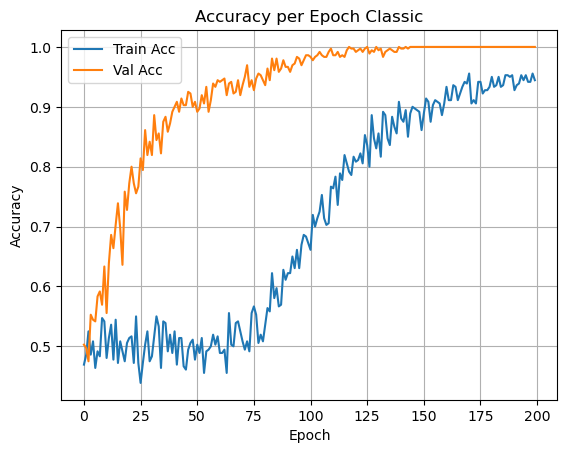

<Figure size 640x480 with 0 Axes>

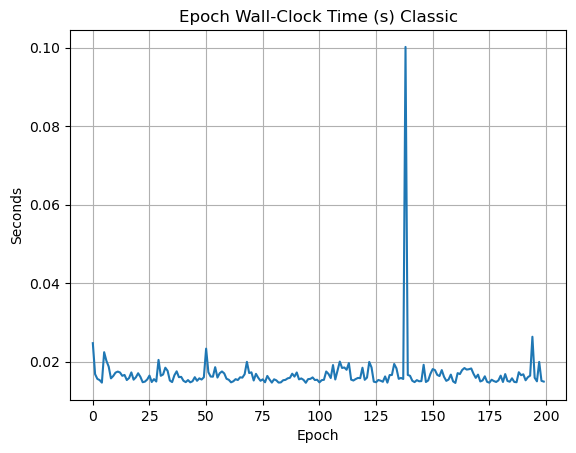

<Figure size 640x480 with 0 Axes>

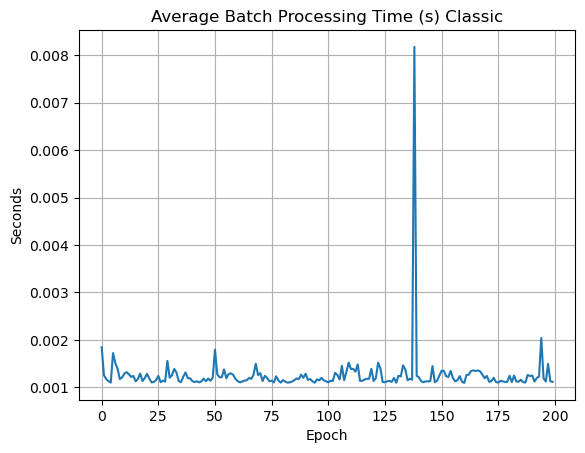

<Figure size 640x480 with 0 Axes>

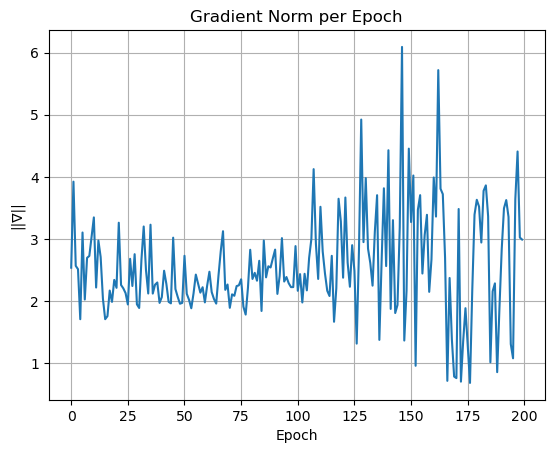

<Figure size 640x480 with 0 Axes>

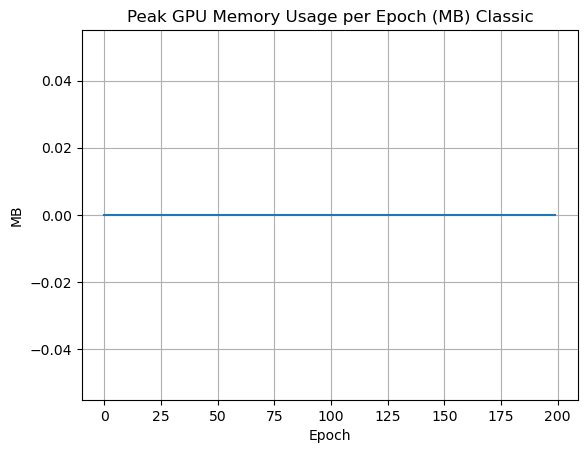


=== Final Test Metrics ===
Threshold: 0.87
Precision: 1.000, Recall: 1.000, F1: 1.000
MCC: 1.000, AUC: 1.000
Confusion Matrix:
 [[304   0]
 [  0  56]]


<Figure size 640x480 with 0 Axes>

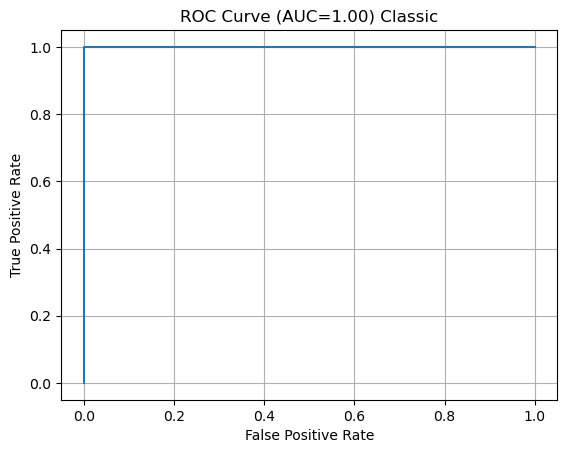

<Figure size 640x480 with 0 Axes>

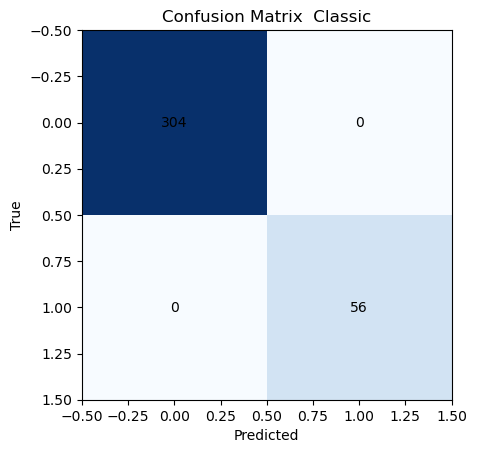

<Figure size 640x480 with 0 Axes>

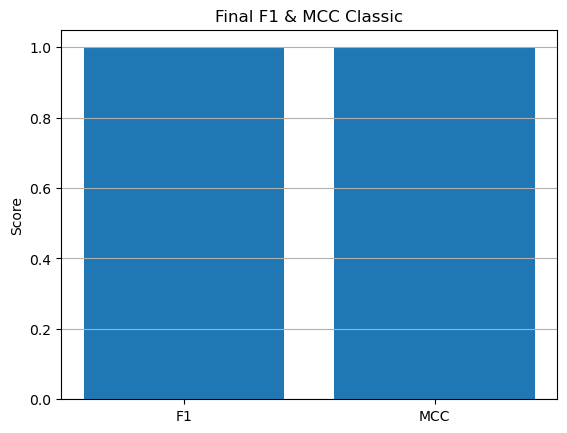

Total end-to-end computation time: 17.28 seconds


<Figure size 640x480 with 0 Axes>

In [50]:
import time
import contextlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset
from sklearn.metrics import (
    precision_recall_fscore_support,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt

# ─── (Optional) for FLOPs & params ───────────────────────────────────────────
# pip install ptflops
from ptflops import get_model_complexity_info

# ─── Data setup ────────────────────────────────────────────────────────────
source_X = torch.randn(360, 100)
source_y = torch.cat([torch.zeros(304), torch.ones(56)])
target_X = torch.randn(200, 100)
target_y = torch.zeros(200)

source_ds = TensorDataset(source_X, source_y)
target_ds = TensorDataset(target_X, target_y)

counts     = np.bincount(source_y.long().numpy().astype(int))
pos_weight = torch.tensor(counts[0] / counts[1], dtype=torch.float)

N              = len(source_y)
class_weights  = torch.tensor([N/(2*c) for c in counts], dtype=torch.float)
sample_weights = class_weights[source_y.long().numpy().astype(int)]
sampler        = WeightedRandomSampler(sample_weights, num_samples=N, replacement=True)

source_loader = DataLoader(source_ds, batch_size=32, sampler=sampler)
target_loader = DataLoader(target_ds, batch_size=32, shuffle=True)
test_loader   = DataLoader(source_ds, batch_size=32, shuffle=False)

# ─── DANN architecture ─────────────────────────────────────────────────────
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

class DANN(nn.Module):
    def __init__(self, input_dim=100, feature_dim=50):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, feature_dim), nn.ReLU()
        )
        self.class_classifier  = nn.Linear(feature_dim, 1)
        self.domain_classifier = nn.Sequential(
            nn.Linear(feature_dim, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x, alpha=1.0):
        feat     = self.feature_extractor(x)
        rev_feat = GradReverse.apply(feat, alpha)
        return (
            self.class_classifier(feat).squeeze(1),
            self.domain_classifier(rev_feat).squeeze(1)
        )

# ─── Training & Validation ──────────────────────────────────────────────────
def train_dann(model, source_loader, target_loader, pos_weight,
               num_epochs=200, device='cpu'):
    model.to(device)
    crit_c = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    crit_d = nn.BCEWithLogitsLoss()
    opt    = optim.Adam(model.parameters(), lr=1e-4)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [], 'val_f1': [], 'val_thr': [],
        'epoch_time': [], 'batch_time': [], 'grad_norm': [], 'peak_mem_MB': []
    }

    for epoch in range(1, num_epochs+1):
        epoch_start = time.time()
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        alpha = 2.0 / (1.0 + np.exp(-10 * epoch / num_epochs)) - 1.0
        tgt_iter = iter(target_loader)

        if device.startswith('cuda'):
            torch.cuda.reset_peak_memory_stats(device)

        batch_times = []

        for x_s, y_s in source_loader:
            batch_start = time.time()
            try:
                x_t, _ = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(target_loader)
                x_t, _ = next(tgt_iter)

            x_s, y_s, x_t = x_s.to(device), y_s.to(device), x_t.to(device)
            opt.zero_grad()
            c_s, d_s     = model(x_s, alpha)
            _,  d_t      = model(x_t, alpha)
            loss_c       = crit_c(c_s, y_s)
            loss_d       = 0.5 * (crit_d(d_s, torch.zeros_like(d_s)) +
                                  crit_d(d_t, torch.ones_like(d_t)))
            loss         = loss_c + alpha * loss_d
            loss.backward()

            # Gradient norm
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.detach().data.norm(2).item() ** 2
            grad_norm = total_norm ** 0.5

            opt.step()

            total_loss += loss.item()
            preds      = (torch.sigmoid(c_s) >= 0.5).long()
            correct   += (preds == y_s.long()).sum().item()
            total     += y_s.size(0)

            batch_times.append(time.time() - batch_start)

        train_loss = total_loss / len(source_loader)
        train_acc  = correct / total

        epoch_time     = time.time() - epoch_start
        avg_batch_time = sum(batch_times) / len(batch_times)
        peak_mem_MB    = (torch.cuda.max_memory_allocated(device) / 1024**2
                          if device.startswith('cuda') else 0.0)

        # ── VALIDATION ─────────────────────────────────────────
        model.eval()
        val_loss, y_true, y_scores = 0.0, [], []
        with torch.no_grad():
            for x_v, y_v in source_loader:
                x_v = x_v.to(device)
                logits, _ = model(x_v, alpha=0.0)
                val_loss += crit_c(logits, y_v.to(device)).item()
                y_true.extend(y_v.int().tolist())
                y_scores.extend(torch.sigmoid(logits).cpu().tolist())

        thresholds = np.linspace(0.01, 0.99, 99)
        best_thr, best_f1 = 0.0, 0.0
        for thr in thresholds:
            preds = (np.array(y_scores) >= thr).astype(int)
            _, _, f1, _ = precision_recall_fscore_support(
                y_true, preds, average='binary', zero_division=0
            )
            if f1 > best_f1:
                best_f1, best_thr = f1, thr

        val_acc = np.mean((np.array(y_scores) >= best_thr).astype(int) == np.array(y_true))
        val_loss /= len(source_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(best_f1)
        history['val_thr'].append(best_thr)
        history['epoch_time'].append(epoch_time)
        history['batch_time'].append(avg_batch_time)
        history['grad_norm'].append(grad_norm)
        history['peak_mem_MB'].append(peak_mem_MB)

        print(f"Epoch {epoch:03d} | "
              f"train_loss={train_loss:.3f}, train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.3f}, val_acc={val_acc:.3f}, val_f1={best_f1:.3f}, thr={best_thr:.2f} | "
              f"epoch_time={epoch_time:.2f}s, batch_time={avg_batch_time:.3f}s, "
              f"grad_norm={grad_norm:.2f}, peak_mem={peak_mem_MB:.1f}MB")

    return history, best_thr

# ─── Final Test Evaluation ──────────────────────────────────────────────────
def evaluate_and_collect_dann(model, loader, thr, device='cpu'):
    model.to(device).eval()
    y_true, y_scores = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            c, _ = model(x, alpha=0.0)
            y_true.extend(y.int().tolist())
            y_scores.extend(torch.sigmoid(c).cpu().tolist())

    preds = (np.array(y_scores) >= thr).astype(int)
    cm    = confusion_matrix(y_true, preds)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc   = roc_auc_score(y_true, y_scores)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, preds, average='binary', zero_division=0
    )
    mcc = matthews_corrcoef(y_true, preds)

    print("\n=== Final Test Metrics ===")
    print(f"Threshold: {thr:.2f}")
    print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")
    print(f"MCC: {mcc:.3f}, AUC: {auc:.3f}")
    print("Confusion Matrix:\n", cm)

    return {'cm': cm, 'fpr': fpr, 'tpr': tpr, 'auc': auc,
            'precision': prec, 'recall': rec, 'f1': f1, 'mcc': mcc}

# ─── Main & Plots ──────────────────────────────────────────────────────────
if __name__ == '__main__':
    # ─── Total‐run timer start ──────────────────────────────
    main_start = time.time()

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model  = DANN(input_dim=100, feature_dim=50)

    # static model stats
    with torch.cuda.device(device) if device.startswith('cuda') else contextlib.nullcontext():
        macs, params = get_model_complexity_info(
            model, (100,), as_strings=False, print_per_layer_stat=False
        )
    print(f"Model Parameters: {params:,}")
    print(f"Approx. FLOPs per forward pass: {macs:,}")

    # Train & validate
    history, final_thr = train_dann(
        model, source_loader, target_loader,
        pos_weight=pos_weight,
        num_epochs=200,
        device=device
    )

    # Total training time
    total_train_time = sum(history['epoch_time'])
    print(f"\nTotal training time (sum of epoch times): {total_train_time:.2f} seconds")

    # Plot loss & accuracy
    plt.figure(); plt.plot(history['train_loss'], label='Train Loss'); plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss per Epoch Classic'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.show()
    plt.savefig("Loss per Epoch_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)
    
    plt.figure(); plt.plot(history['train_acc'], label='Train Acc'); plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy per Epoch Classic'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True); plt.show()
    plt.savefig("Accuracy per Epoch_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    # Resource & gradient plots
    plt.figure(); plt.plot(history['epoch_time'])
    plt.title('Epoch Wall-Clock Time (s) Classic'); plt.xlabel('Epoch'); plt.ylabel('Seconds'); plt.grid(True); plt.show()
    plt.savefig("Epoch Wall-Clock Time (s)_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    plt.figure(); plt.plot(history['batch_time'])
    plt.title('Average Batch Processing Time (s) Classic'); plt.xlabel('Epoch'); plt.ylabel('Seconds'); plt.grid(True); plt.show()
    plt.savefig("Average Batch Processing Time (s)_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    plt.figure(); plt.plot(history['grad_norm'])
    plt.title('Gradient Norm per Epoch'); plt.xlabel('Epoch'); plt.ylabel('||∇||'); plt.grid(True); plt.show()
    plt.savefig("Gradient Norm per Epoch_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    plt.figure(); plt.plot(history['peak_mem_MB'])
    plt.title('Peak GPU Memory Usage per Epoch (MB) Classic'); plt.xlabel('Epoch'); plt.ylabel('MB'); plt.grid(True); plt.show()
    plt.savefig("Peak GPU Memory Usage per Epoch (MB)_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    # Final test evaluation & original plots
    results = evaluate_and_collect_dann(model, test_loader, final_thr, device=device)

    plt.figure(); plt.plot(results['fpr'], results['tpr'])
    plt.title(f"ROC Curve (AUC={results['auc']:.2f}) Classic"); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.grid(True); plt.show()
    plt.savefig("ROC Curve_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    cm = results['cm']
    plt.figure(); plt.imshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center')
    plt.title('Confusion Matrix  Classic'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()
    plt.savefig("Confusion Matrix_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    plt.figure(); plt.bar(['F1','MCC'], [results['f1'], results['mcc']])
    plt.title('Final F1 & MCC Classic'); plt.ylabel('Score'); plt.grid(axis='y'); plt.show()
    plt.savefig("Final F1 & MCC_Classic.pdf",
            format="pdf",
            dpi=300,
            bbox_inches="tight",
            transparent=False)

    # ─── Total‐run timer end ───────────────────────────────
    total_main_time = time.time() - main_start
    print(f"Total end-to-end computation time: {total_main_time:.2f} seconds")


### Code for Reviewer. Query: "Given the `compact/standardized' selling point, comparisons should include lightweight classical models (e.g., logistic regression/MLP/SVM) with similar parameter budgets, not only CNN/Transformer. Otherwise, `slightly behind SOTA but small' lacks a fair budget-matched comparator."

In [1]:
import os, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# ────────────────────────────── Reproducibility ─────────────────────────────

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ──────────────────────────────── Dataset ───────────────────────────────────

class GaitDataset(Dataset):
    """
    Dataset for spectrogram-like gait images stored as
    processed_images/clase_0/*.png and processed_images/clase_1/*.png
    """
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for lbl, cls in enumerate(["clase_0", "clase_1"]):
            folder = os.path.join(root_dir, cls)
            if not os.path.isdir(folder):
                raise FileNotFoundError(f"Folder not found: {folder}")
            for fn in sorted(os.listdir(folder)):
                if fn.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(folder, fn), lbl))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, lbl = self.samples[idx]
        img = Image.open(path).convert("L")   # grayscale
        if self.transform is not None:
            img = self.transform(img)
        label = torch.tensor(lbl, dtype=torch.long)
        return img, label

# ──────────────────────────── Transforms & Splits ───────────────────────────

root_dir = "processed_images"

train_tf = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Two dataset instances: one with augmentation (train), one without (val/test)
train_dataset = GaitDataset(root_dir, transform=train_tf)
eval_dataset  = GaitDataset(root_dir, transform=eval_tf)

N = len(train_dataset)
print(f"Total number of images found: {N}")
indices = list(range(N))
random.shuffle(indices)

n_train = int(0.8 * N)
n_val   = int(0.1 * N)
train_indices = indices[:n_train]
val_indices   = indices[n_train:n_train + n_val]
test_indices  = indices[n_train + n_val:]

print(f"Split sizes: train={len(train_indices)}, "
      f"val={len(val_indices)}, test={len(test_indices)}")

train_subset = Subset(train_dataset, train_indices)  # augmented
val_subset   = Subset(eval_dataset,  val_indices)    # no augmentation
test_subset  = Subset(eval_dataset,  test_indices)   # no augmentation

batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_subset,  batch_size=batch_size, shuffle=False)

# ─────────────────────────── Class imbalance weights ────────────────────────

def compute_pos_weight(base_dataset, idxs):
    """
    Compute pos_weight for BCEWithLogitsLoss from the underlying labels
    (before augmentation), using indices into the non-augmented dataset.
    """
    labels = []
    for i in idxs:
        _, lbl = base_dataset[i]  # this dataset may have any transform; only labels matter
        labels.append(int(lbl.item()))
    labels = np.array(labels, dtype=int)
    counts = np.bincount(labels, minlength=2)
    neg, pos = counts[0], counts[1]
    if pos == 0:
        raise ValueError("No positive samples in training set, cannot compute pos_weight.")
    pos_weight = neg / float(pos)
    return torch.tensor(pos_weight, dtype=torch.float32), counts

# For pos_weight we can use the eval_dataset (or train_dataset) for labels;
# transforms do not affect labels.
pos_weight, class_counts = compute_pos_weight(eval_dataset, train_indices)
print(f"Train class counts: {class_counts}, pos_weight={pos_weight:.3f}")

# ────────────────────────────── Model definitions ──────────────────────────

class LogisticRegressionNet(nn.Module):
    """
    Flatten -> Linear(in_dim -> 1)
    Parameter count: in_dim + 1
    """
    def __init__(self, in_dim: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, x):
        x = self.flatten(x)
        logits = self.fc(x)
        return logits.squeeze(1)

class TinyMLPNet(nn.Module):
    """
    Flatten -> Linear(in_dim -> hidden_dim) -> ReLU -> Linear(hidden_dim -> 1)
    Example: in_dim=480, hidden_dim=8 gives ~3.9k parameters (QT-like budget).
    """
    def __init__(self, in_dim: int, hidden_dim: int = 8):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits.squeeze(1)

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ───────────────────── Training / Validation loop ──────────────────────────

def train_light_model(model,
                      train_loader,
                      val_loader,
                      pos_weight,
                      lr=1e-3,
                      weight_decay=1e-4,
                      num_epochs=100,
                      patience=10,
                      device=device):
    """
    Train a lightweight model with class-weighted BCEWithLogitsLoss and
    validation F1-based threshold calibration. Early stopping on val-F1.
    """
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_f1 = -1.0
    best_thr = 0.5
    epochs_without_improve = 0

    for epoch in range(1, num_epochs + 1):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        n_train = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y.float())
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            n_train += x.size(0)

        train_loss = running_loss / max(n_train, 1)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        n_val = 0
        y_true = []
        y_scores = []

        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                logits_val = model(x_val)
                loss_val = criterion(logits_val, y_val.float().to(device))
                val_loss += loss_val.item() * x_val.size(0)
                n_val += x_val.size(0)

                y_true.extend(y_val.numpy().tolist())
                y_scores.extend(torch.sigmoid(logits_val).cpu().numpy().tolist())

        val_loss = val_loss / max(n_val, 1)

        y_true_arr = np.array(y_true, dtype=int)
        y_scores_arr = np.array(y_scores, dtype=float)

        # Threshold sweep for F1 calibration
        thresholds = np.linspace(0.01, 0.99, 99)
        best_epoch_f1 = -1.0
        best_epoch_thr = 0.5
        for thr in thresholds:
            y_pred = (y_scores_arr >= thr).astype(int)
            _, _, f1, _ = precision_recall_fscore_support(
                y_true_arr, y_pred, average="binary", zero_division=0
            )
            if f1 > best_epoch_f1:
                best_epoch_f1 = f1
                best_epoch_thr = thr

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_F1={best_epoch_f1:.4f} "
              f"@thr={best_epoch_thr:.2f}")

        # Early stopping on val-F1
        if best_epoch_f1 > best_val_f1 + 1e-4:
            best_val_f1 = best_epoch_f1
            best_thr = best_epoch_thr
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= patience:
                print(f"Early stopping at epoch {epoch} "
                      f"(no improvement in val-F1 for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_thr, best_val_f1

# ───────────────────────────── Test evaluation ─────────────────────────────

def evaluate_on_test(model, loader, thr, device=device):
    """
    Evaluate a trained model on a held-out test loader at a fixed threshold.
    """
    model = model.to(device)
    model.eval()

    y_true = []
    y_scores = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            y_true.extend(y.numpy().tolist())
            y_scores.extend(torch.sigmoid(logits).cpu().numpy().tolist())

    y_true_arr = np.array(y_true, dtype=int)
    y_scores_arr = np.array(y_scores, dtype=float)

    y_pred = (y_scores_arr >= thr).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_arr, y_pred, average="binary", zero_division=0
    )
    acc = (y_pred == y_true_arr).mean()
    cm = confusion_matrix(y_true_arr, y_pred)

    print(f"Test metrics @thr={thr:.2f}: "
          f"acc={acc:.4f}, F1={f1:.4f}, precision={prec:.4f}, recall={rec:.4f}")
    print("Test confusion matrix:\n", cm)

    return {
        "accuracy": float(acc),
        "f1": float(f1),
        "precision": float(prec),
        "recall": float(rec),
        "cm": cm
    }

# ────────────────────────────────── Main ────────────────────────────────────

def main():
    # Input images are 1×H×W; in our processed_images they are 40×12
    in_h, in_w = 40, 12
    in_dim = in_h * in_w

    # ---------------- Logistic Regression baseline -----------------
    log_model = LogisticRegressionNet(in_dim=in_dim)
    log_params = count_parameters(log_model)
    print("\n=== Logistic Regression baseline ===")
    print(f"Number of trainable parameters: {log_params}")

    log_model, log_thr, log_best_val_f1 = train_light_model(
        log_model,
        train_loader,
        val_loader,
        pos_weight=pos_weight,
        lr=1e-3,
        weight_decay=1e-4,
        num_epochs=80,
        patience=10,
        device=device
    )
    log_test_results = evaluate_on_test(
        log_model,
        test_loader,
        thr=log_thr,
        device=device
    )

    # ---------------- Tiny MLP baseline (QT-like budget) -------------
    hidden_units = 8  # ~3.9k parameters for in_dim=480
    mlp_model = TinyMLPNet(in_dim=in_dim, hidden_dim=hidden_units)
    mlp_params = count_parameters(mlp_model)
    print(f"\n=== Tiny MLP baseline (hidden_dim={hidden_units}) ===")
    print(f"Number of trainable parameters: {mlp_params}")

    mlp_model, mlp_thr, mlp_best_val_f1 = train_light_model(
        mlp_model,
        train_loader,
        val_loader,
        pos_weight=pos_weight,
        lr=5e-4,
        weight_decay=1e-4,
        num_epochs=120,
        patience=12,
        device=device
    )
    mlp_test_results = evaluate_on_test(
        mlp_model,
        test_loader,
        thr=mlp_thr,
        device=device
    )

    # ------------------- Summary for the reviewer --------------------
    # QT parameter count from the main manuscript:
    QT_PARAM_COUNT = 3893  # 3,848 classical + 45 QT parameters

    print("\n==== Lightweight Baseline Summary (for reviewer) ====")
    print(f"QT total trainable parameter count (from main text): {QT_PARAM_COUNT}")

    print(
        "Logistic baseline: "
        f"params={log_params}, "
        f"params/QT={log_params/QT_PARAM_COUNT:.3f}, "
        f"best_val_F1={log_best_val_f1:.4f}, "
        f"test_acc={log_test_results['accuracy']:.4f}, "
        f"test_F1={log_test_results['f1']:.4f}, "
        f"test_precision={log_test_results['precision']:.4f}, "
        f"test_recall={log_test_results['recall']:.4f}, "
        f"test_cm={log_test_results['cm'].tolist()}"
    )

    print(
        "Tiny MLP baseline: "
        f"params={mlp_params}, "
        f"params/QT={mlp_params/QT_PARAM_COUNT:.3f}, "
        f"best_val_F1={mlp_best_val_f1:.4f}, "
        f"test_acc={mlp_test_results['accuracy']:.4f}, "
        f"test_F1={mlp_test_results['f1']:.4f}, "
        f"test_precision={mlp_test_results['precision']:.4f}, "
        f"test_recall={mlp_test_results['recall']:.4f}, "
        f"test_cm={mlp_test_results['cm'].tolist()}"
    )

    print(
        "\nCopy the two summary lines above into the response so that we can\n"
        "add a budget-matched comparison paragraph to the manuscript."
    )

if __name__ == "__main__":
    main()

Using device: cpu
Total number of images found: 1238
Split sizes: train=990, val=123, test=125
Train class counts: [493 497], pos_weight=0.992

=== Logistic Regression baseline ===
Number of trainable parameters: 481
Epoch 001 | train_loss=0.6787 | val_loss=0.6570 | val_F1=0.6716 @thr=0.47
Epoch 002 | train_loss=0.6185 | val_loss=0.6237 | val_F1=0.7328 @thr=0.46
Epoch 003 | train_loss=0.5972 | val_loss=0.6071 | val_F1=0.7328 @thr=0.45
Epoch 004 | train_loss=0.5840 | val_loss=0.5879 | val_F1=0.7385 @thr=0.46
Epoch 005 | train_loss=0.5680 | val_loss=0.5804 | val_F1=0.7520 @thr=0.49
Epoch 006 | train_loss=0.5624 | val_loss=0.5683 | val_F1=0.7563 @thr=0.50
Epoch 007 | train_loss=0.5506 | val_loss=0.5758 | val_F1=0.7458 @thr=0.50
Epoch 008 | train_loss=0.5521 | val_loss=0.5674 | val_F1=0.7516 @thr=0.29
Epoch 009 | train_loss=0.5412 | val_loss=0.5550 | val_F1=0.7705 @thr=0.49
Epoch 010 | train_loss=0.5361 | val_loss=0.5579 | val_F1=0.7552 @thr=0.35
Epoch 011 | train_loss=0.5356 | val_loss=0.